In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Load cleaned dataset
df = pd.read_csv(r"C:\Users\Pravallika Dheshidi\OneDrive\Documents\GitHub\team9_PyCoders_PythonHackathon_MAY2026\cleaned_data_PD.csv")

# BASIC INFORMATION#
## Reasoning:
### This analysis helps understand:
Number of rows and columns
Available variables
Data structure and formatting
It is important because healthcare datasets often contain large time-series records, and understanding the structure is necessary before deeper analysis.

In [14]:
print("First 5 Rows")
print(df.head())

First 5 Rows
                  time  glucose  calories  heart_rate  steps  basal_rate  \
0  2018-06-13 18:40:00    332.0      6.36       82.32   34.0    0.091667   
1  2018-06-13 18:45:00    326.0      7.73       83.74    0.0    0.091667   
2  2018-06-13 18:50:00    330.0      4.75       80.53    0.0    0.091667   
3  2018-06-13 18:55:00    324.0      6.36       89.13   20.0    0.091667   
4  2018-06-13 19:00:00    306.0      5.15       92.50    0.0    0.075000   

   bolus_volume_delivered  carb_input Patient_ID  Age Gender   Race  \
0                     0.0         0.0  HUPA0001P   34   Male  Other   
1                     0.0         0.0  HUPA0001P   34   Male  Other   
2                     0.0         0.0  HUPA0001P   34   Male  Other   
3                     0.0         0.0  HUPA0001P   34   Male  Other   
4                     0.0         0.0  HUPA0001P   34   Male  Other   

   Average Sleep Duration (hrs)  Sleep Quality (1-10)  \
0                           6.3               

In [15]:
print("\nDataset Shape")
print(df.shape)


Dataset Shape
(309392, 15)


In [16]:
print("\nColumn Names")
print(df.columns)


Column Names
Index(['time', 'glucose', 'calories', 'heart_rate', 'steps', 'basal_rate',
       'bolus_volume_delivered', 'carb_input', 'Patient_ID', 'Age', 'Gender',
       'Race', 'Average Sleep Duration (hrs)', 'Sleep Quality (1-10)',
       '% with Sleep Disturbances'],
      dtype='object')


# Missing Values Analysis (isnull().sum())
## Reasoning: 
### Medical datasets frequently contain missing sensor readings due to:
CGM sensor interruptions,Fitbit sync failures,Missing meal or insulin entries
### Checking missing values ensures:
Data quality,Reliable model performance,Accurate statistical analysis.

In [17]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
time                            0
glucose                         0
calories                        0
heart_rate                      0
steps                           0
basal_rate                      0
bolus_volume_delivered          0
carb_input                      0
Patient_ID                      0
Age                             0
Gender                          0
Race                            0
Average Sleep Duration (hrs)    0
Sleep Quality (1-10)            0
% with Sleep Disturbances       0
dtype: int64


# Summary Statistics (describe())
## Reasoning: 
### Summary statistics provide:
Mean,Standard deviation,Minimum/maximum values
### This helps identify:
Average glucose levels
Glucose variability
Abnormal insulin or activity values
Outliers
In diabetes analysis, glucose variability is clinically important because extreme highs and lows are dangerous.

In [18]:
print("\nSummary Statistics")
print(df.describe())


Summary Statistics
             glucose       calories     heart_rate          steps  \
count  309392.000000  309392.000000  309392.000000  309392.000000   
mean      141.425051       8.813100      76.990004      30.825005   
std        57.085587       6.930581      15.546697      84.981109   
min        40.000000       0.000000      32.410000       0.000000   
25%        99.670000       5.850000      64.930000       0.000000   
50%       132.000000       6.280000      75.420000       0.000000   
75%       173.000000       9.190000      85.610000      11.000000   
max       444.000000     106.350000     195.620000     842.000000   

          basal_rate  bolus_volume_delivered     carb_input            Age  \
count  309392.000000           309392.000000  309392.000000  309392.000000   
mean        0.041324                0.066058       0.052718      53.332727   
std         0.036106                0.755075       1.505433      12.421322   
min         0.000000               -3.000000  

In [25]:
# -------------------------------
# IMPORTANT COLUMNS FOR ANALYSIS
# -------------------------------
important_cols = [
    'glucose',
    'carb_input',
    'bolus_vol',
    'basal_rate',
    'steps',
    'heart_rate',
    'calories',
    'Sleep Qua',
    '% with Sleep Disturbances'
]



# Why These Columns Were Selected
These columns were selected because they collectively represent the key physiological, behavioral, and lifestyle factors that influence glucose levels in individuals with diabetes. Glucose is the primary outcome variable being studied, while carb_input directly affects post-meal glucose spikes. Insulin-related features such as bolus_vol and basal_rate are included to capture how insulin dosing helps regulate and stabilize blood glucose levels. Activity and stress-related indicators like heart_rate, steps, and calories are important because physical activity and energy expenditure significantly impact insulin sensitivity and glucose metabolism. Additionally, sleep-related metrics such as Sleep Qua and % with Sleep Disturbances are included since poor or disrupted sleep can negatively affect hormonal balance and lead to greater glucose variability. Together, these features provide a comprehensive view of the factors influencing glucose control.

In [ ]:
# -------------------------------
# DESCRIPTIVE ANALYSIS
# -------------------------------

In [19]:
# Average values
print("\nAverage Glucose:", df['glucose'].mean())
print("Average Steps:", df['steps'].mean())
print("Average Heart Rate:", df['heart_rate'].mean())


Average Glucose: 141.42505097093655
Average Steps: 30.825005171433006
Average Heart Rate: 76.99000378161038


# 1.Glucose Distribution Histogram
## Reasoning
### The histogram helps visualize:
Whether glucose values are normally distributed
Frequency of hyperglycemia (high glucose)
Frequency of hypoglycemia (low glucose)

### This is important because:
Diabetes management focuses on maintaining glucose within a safe range
Distribution patterns help assess patient stability

A wide spread may indicate poor glycemic control.

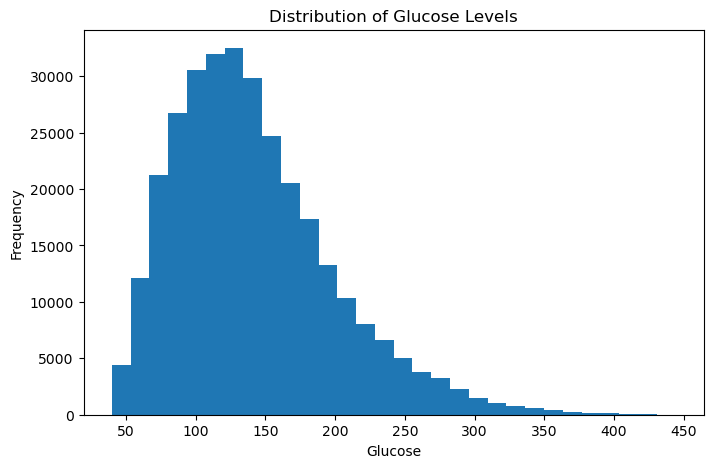

In [20]:
# -------------------------------
# GLUCOSE DISTRIBUTION
# -------------------------------

plt.figure(figsize=(8,5))
plt.hist(df['glucose'], bins=30)
plt.title("Distribution of Glucose Levels")
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.show()

# 2. Glucose Trend Over Time
## Reasoning
CGM data is time-series data, so analyzing glucose trends over time helps identify:
Daily glucose patterns
Meal-related spikes
Overnight glucose behavior
Sudden glucose drops

## This analysis is essential for:
Detecting dangerous glucose fluctuations
Understanding patient behavior
Building future prediction models

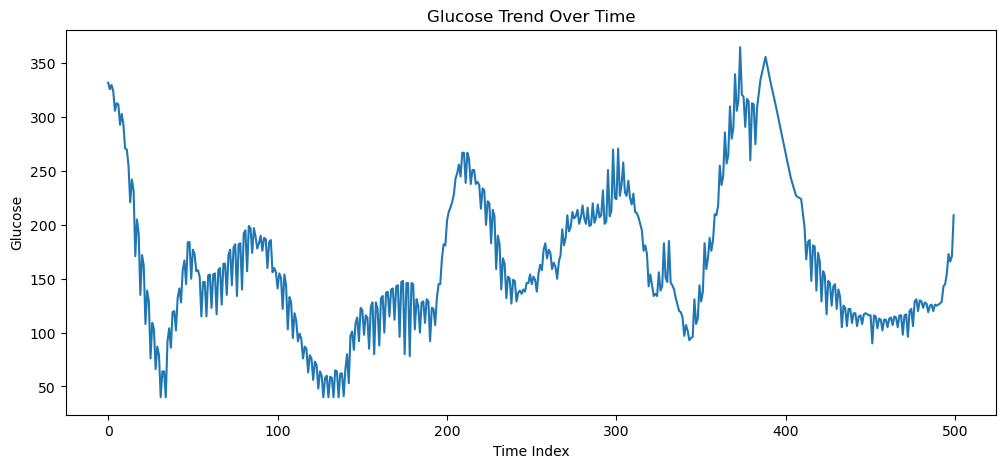

In [21]:
# -------------------------------
# GLUCOSE TREND
# -------------------------------

plt.figure(figsize=(12,5))
plt.plot(df['glucose'][:500])
plt.title("Glucose Trend Over Time")
plt.xlabel("Time Index")
plt.ylabel("Glucose")
plt.show()

# 3.Steps vs Glucose Scatter Plot
## Reasoning
Physical activity increases insulin sensitivity and often lowers glucose levels.
### This analysis helps determine:
Whether active patients maintain better glucose control
Relationship between movement and glucose reduction
### The scatter plot visually identifies:
Positive correlation
Negative correlation
Weak/no relationship

This supports lifestyle-based diabetes recommendations.

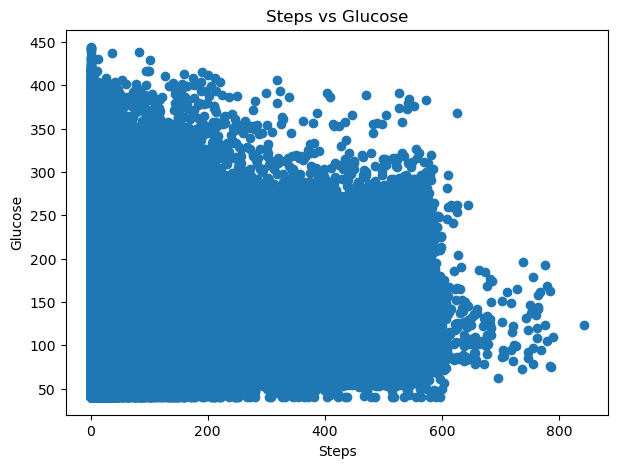

In [22]:
# -------------------------------
# STEPS VS GLUCOSE
# -------------------------------

plt.figure(figsize=(7,5))
plt.scatter(df['steps'], df['glucose'])
plt.title("Steps vs Glucose")
plt.xlabel("Steps")
plt.ylabel("Glucose")
plt.show()


# 4.Heart Rate vs Glucose
## Reasoning
### Heart rate reflects:
Physical exertion
Stress levels
Physiological response
### Changes in heart rate may affect glucose because:
Exercise lowers glucose
Stress hormones can increase glucose
This analysis helps study physiological effects on diabetes management.

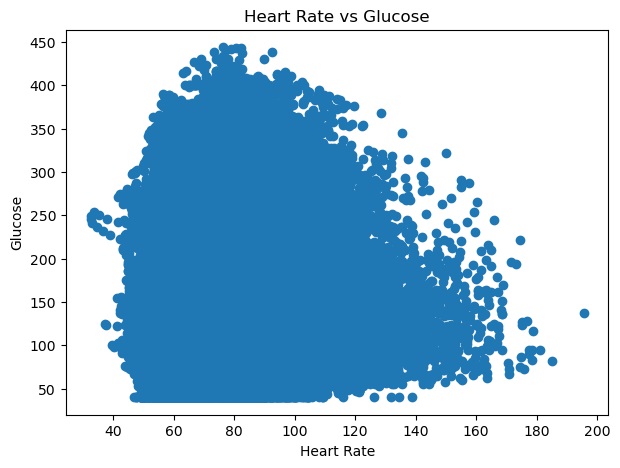

In [23]:
# -------------------------------
# HEART RATE VS GLUCOSE
# -------------------------------

plt.figure(figsize=(7,5))
plt.scatter(df['heart_rate'], df['glucose'])
plt.title("Heart Rate vs Glucose")
plt.xlabel("Heart Rate")
plt.ylabel("Glucose")
plt.show()
